Saving 6. SOT J sweep.txt to 6. SOT J sweep (1).txt
315 runs | JHM 0.00-14.00 e12 A/m^2 | tpulse 0.00-2.00 ns

Threshold current per tpulse (lowest switching JHM):
  tpulse= 0.00 ns : Jc = no switch
  tpulse= 0.10 ns : Jc = 4.00 e12
  tpulse= 0.20 ns : Jc = 3.00 e12
  tpulse= 0.30 ns : Jc = 3.00 e12
  tpulse= 0.40 ns : Jc = 3.00 e12
  tpulse= 0.50 ns : Jc = 2.00 e12
  tpulse= 0.60 ns : Jc = 2.00 e12
  tpulse= 0.70 ns : Jc = 2.00 e12
  tpulse= 0.80 ns : Jc = 2.00 e12
  tpulse= 0.90 ns : Jc = 2.00 e12
  tpulse= 1.00 ns : Jc = 2.00 e12
  tpulse= 1.10 ns : Jc = 2.00 e12
  tpulse= 1.20 ns : Jc = 2.00 e12
  tpulse= 1.30 ns : Jc = 2.00 e12
  tpulse= 1.40 ns : Jc = 2.00 e12
  tpulse= 1.50 ns : Jc = 2.00 e12
  tpulse= 1.60 ns : Jc = 2.00 e12
  tpulse= 1.70 ns : Jc = 2.00 e12
  tpulse= 1.80 ns : Jc = 2.00 e12
  tpulse= 1.90 ns : Jc = 2.00 e12
  tpulse= 2.00 ns : Jc = 2.00 e12

Plateau (quasi-static) Jc = 2.00 e12 A/m^2
Operating point 1.2 x Jc  = 2.40 e12 A/m^2
First-principles ~1-1.5 e12 -> con

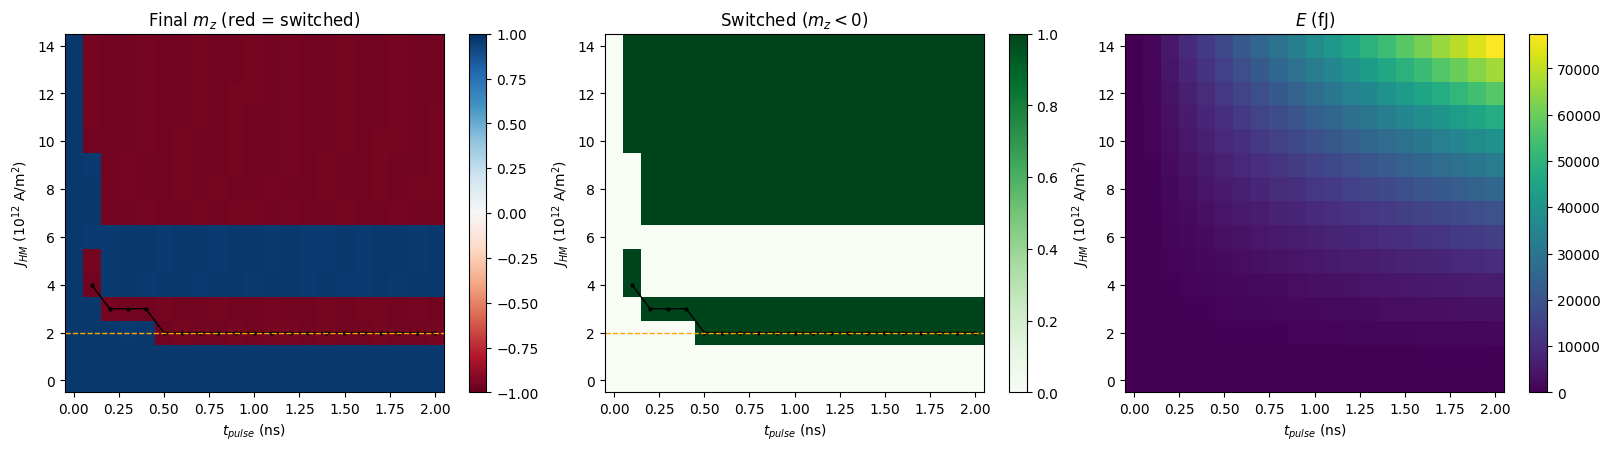

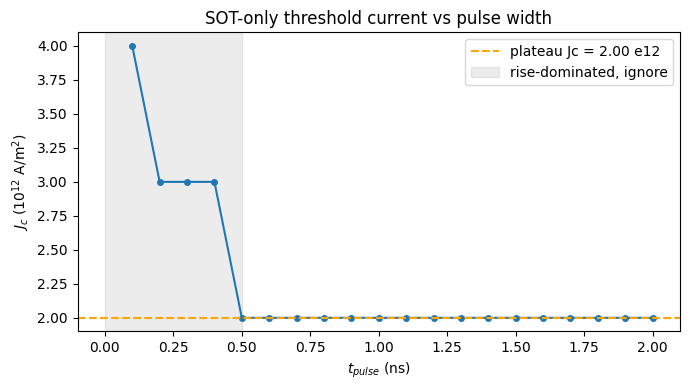

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, io
from google.colab import files

# --- upload the COMSOL export ---
uploaded = files.upload()
fname = next(iter(uploaded))

# Columns from Global Evaluation (Time selection = Last):
#   JHM, tpulse, [time], mz_final, sw_flag, E
cols = ["JHM", "tpulse", "time", "mz_final", "sw_flag", "E"]
df = pd.read_csv(io.BytesIO(uploaded[fname]), comment="%", sep=r"\s+",
                 header=None, names=cols)
df = df.drop(columns="time", errors="ignore")

df["tpulse_ns"] = df["tpulse"] * 1e9
df["JHM_e12"]   = df["JHM"] / 1e12
df["E_fJ"]      = df["E"] * 1e15
df["sw_real"]   = df["sw_flag"] > 0
df = df.sort_values(["JHM", "tpulse"]).reset_index(drop=True)

print(f"{len(df)} runs | JHM {df.JHM_e12.min():.2f}-{df.JHM_e12.max():.2f} e12 A/m^2 | "
      f"tpulse {df.tpulse_ns.min():.2f}-{df.tpulse_ns.max():.2f} ns")

# --- pivot to grids (rows=JHM, cols=tpulse) ---
mz = df.pivot(index="JHM", columns="tpulse_ns", values="mz_final")
sw = df.pivot(index="JHM", columns="tpulse_ns", values="sw_real").astype(float)
en = df.pivot(index="JHM", columns="tpulse_ns", values="E_fJ")
J, T = mz.index.values, mz.columns.values

def edges(x):
    x = np.asarray(x, float)
    return np.r_[x[0]-(x[1]-x[0])/2, (x[:-1]+x[1:])/2, x[-1]+(x[-1]-x[-2])/2]
Te, Je = edges(T), edges(J/1e12)

# --- Jc per tpulse: lowest JHM giving a switch ---
print("\nThreshold current per tpulse (lowest switching JHM):")
jc_rows = []
for t in T:
    col = sw[t]
    sw_J = col.index[col.values > 0]
    jc = sw_J.min() if len(sw_J) else np.nan
    jc_rows.append((t, jc))
    tag = f"{jc/1e12:.2f} e12" if np.isfinite(jc) else "no switch"
    print(f"  tpulse={t:5.2f} ns : Jc = {tag}")

jc_df = pd.DataFrame(jc_rows, columns=["tpulse_ns", "Jc"]).dropna()

# --- plateau Jc: median over long pulses (>=1 ns); ignore rise-dominated <0.5 ns ---
plateau = jc_df[jc_df.tpulse_ns >= 1.0]
Jc_plateau = plateau.Jc.median() if len(plateau) else np.nan
if np.isfinite(Jc_plateau):
    print(f"\nPlateau (quasi-static) Jc = {Jc_plateau/1e12:.2f} e12 A/m^2")
    print(f"Operating point 1.2 x Jc  = {1.2*Jc_plateau/1e12:.2f} e12 A/m^2")
    print("First-principles ~1-1.5 e12 -> "
          + ("consistent" if 0.7e12 <= Jc_plateau <= 2.0e12
             else "MISMATCH, recheck Ms/theta_SH/Hk"))
else:
    print("\nNo plateau Jc (no long-pulse switching)")

# --- maps ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
p0 = ax[0].pcolormesh(Te, Je, mz.values, cmap="RdBu", vmin=-1, vmax=1)
ax[0].set_title(r"Final $m_z$ (red = switched)"); fig.colorbar(p0, ax=ax[0])
p1 = ax[1].pcolormesh(Te, Je, sw.values, cmap="Greens", vmin=0, vmax=1)
ax[1].set_title(r"Switched ($m_z<0$)"); fig.colorbar(p1, ax=ax[1])
p2 = ax[2].pcolormesh(Te, Je, en.values, cmap="viridis")
ax[2].set_title(r"$E$ (fJ)"); fig.colorbar(p2, ax=ax[2])
for a in ax[:2]:
    a.plot(jc_df.tpulse_ns, jc_df.Jc/1e12, "k.-", lw=1, ms=4)
    if np.isfinite(Jc_plateau):
        a.axhline(Jc_plateau/1e12, color="orange", ls="--", lw=1)
for a in ax:
    a.set_xlabel(r"$t_{pulse}$ (ns)"); a.set_ylabel(r"$J_{HM}$ ($10^{12}$ A/m$^2$)")
plt.show()

# --- Jc vs tpulse curve (the deliverable plot) ---
plt.figure(figsize=(7, 4))
plt.plot(jc_df.tpulse_ns, jc_df.Jc/1e12, "o-", ms=4)
if np.isfinite(Jc_plateau):
    plt.axhline(Jc_plateau/1e12, color="orange", ls="--",
                label=f"plateau Jc = {Jc_plateau/1e12:.2f} e12")
plt.axvspan(0, 0.5, color="grey", alpha=0.15, label="rise-dominated, ignore")
plt.xlabel(r"$t_{pulse}$ (ns)"); plt.ylabel(r"$J_c$ ($10^{12}$ A/m$^2$)")
plt.title("SOT-only threshold current vs pulse width")
plt.legend(); plt.tight_layout(); plt.show()

Saving 7. SOT monotone confirm.txt to 7. SOT monotone confirm.txt
252 runs | JHM 14.00-25.00 e12 A/m^2 | tpulse 0.00-2.00 ns

Threshold current per tpulse (lowest switching JHM):
  tpulse= 0.00 ns : Jc = no switch
  tpulse= 0.10 ns : Jc = 14.00 e12
  tpulse= 0.20 ns : Jc = 14.00 e12
  tpulse= 0.30 ns : Jc = 14.00 e12
  tpulse= 0.40 ns : Jc = 14.00 e12
  tpulse= 0.50 ns : Jc = 14.00 e12
  tpulse= 0.60 ns : Jc = 14.00 e12
  tpulse= 0.70 ns : Jc = 14.00 e12
  tpulse= 0.80 ns : Jc = 14.00 e12
  tpulse= 0.90 ns : Jc = 14.00 e12
  tpulse= 1.00 ns : Jc = 14.00 e12
  tpulse= 1.10 ns : Jc = 14.00 e12
  tpulse= 1.20 ns : Jc = 14.00 e12
  tpulse= 1.30 ns : Jc = 14.00 e12
  tpulse= 1.40 ns : Jc = 14.00 e12
  tpulse= 1.50 ns : Jc = 14.00 e12
  tpulse= 1.60 ns : Jc = 14.00 e12
  tpulse= 1.70 ns : Jc = 14.00 e12
  tpulse= 1.80 ns : Jc = 14.00 e12
  tpulse= 1.90 ns : Jc = 14.00 e12
  tpulse= 2.00 ns : Jc = 14.00 e12

Plateau (quasi-static) Jc = 14.00 e12 A/m^2
Operating point 1.2 x Jc  = 16.80 e12 A/m

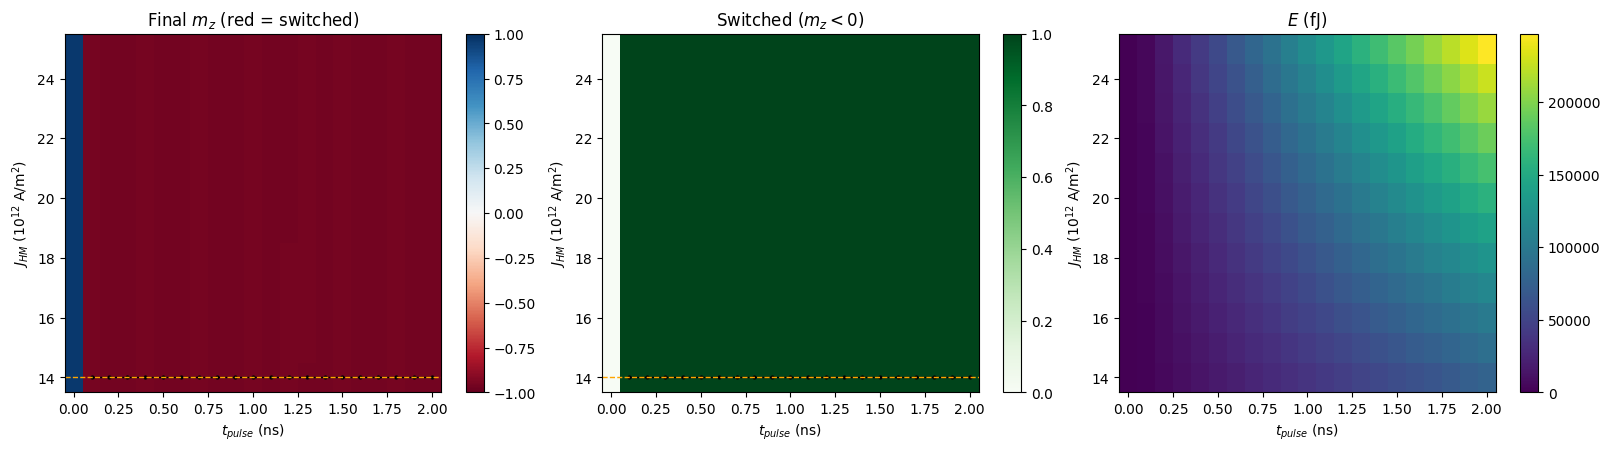

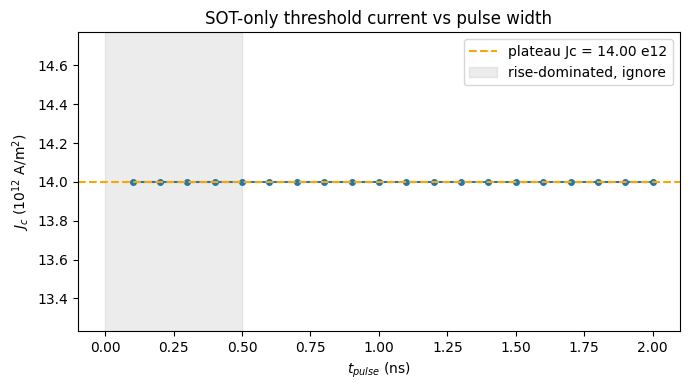

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, io
from google.colab import files

# --- upload the COMSOL export ---
uploaded = files.upload()
fname = next(iter(uploaded))

# Columns from Global Evaluation (Time selection = Last):
#   JHM, tpulse, [time], mz_final, sw_flag, E
cols = ["JHM", "tpulse", "time", "mz_final", "sw_flag", "E"]
df = pd.read_csv(io.BytesIO(uploaded[fname]), comment="%", sep=r"\s+",
                 header=None, names=cols)
df = df.drop(columns="time", errors="ignore")

df["tpulse_ns"] = df["tpulse"] * 1e9
df["JHM_e12"]   = df["JHM"] / 1e12
df["E_fJ"]      = df["E"] * 1e15
df["sw_real"]   = df["sw_flag"] > 0
df = df.sort_values(["JHM", "tpulse"]).reset_index(drop=True)

print(f"{len(df)} runs | JHM {df.JHM_e12.min():.2f}-{df.JHM_e12.max():.2f} e12 A/m^2 | "
      f"tpulse {df.tpulse_ns.min():.2f}-{df.tpulse_ns.max():.2f} ns")

# --- pivot to grids (rows=JHM, cols=tpulse) ---
mz = df.pivot(index="JHM", columns="tpulse_ns", values="mz_final")
sw = df.pivot(index="JHM", columns="tpulse_ns", values="sw_real").astype(float)
en = df.pivot(index="JHM", columns="tpulse_ns", values="E_fJ")
J, T = mz.index.values, mz.columns.values

def edges(x):
    x = np.asarray(x, float)
    return np.r_[x[0]-(x[1]-x[0])/2, (x[:-1]+x[1:])/2, x[-1]+(x[-1]-x[-2])/2]
Te, Je = edges(T), edges(J/1e12)

# --- Jc per tpulse: lowest JHM giving a switch ---
print("\nThreshold current per tpulse (lowest switching JHM):")
jc_rows = []
for t in T:
    col = sw[t]
    sw_J = col.index[col.values > 0]
    jc = sw_J.min() if len(sw_J) else np.nan
    jc_rows.append((t, jc))
    tag = f"{jc/1e12:.2f} e12" if np.isfinite(jc) else "no switch"
    print(f"  tpulse={t:5.2f} ns : Jc = {tag}")

jc_df = pd.DataFrame(jc_rows, columns=["tpulse_ns", "Jc"]).dropna()

# --- plateau Jc: median over long pulses (>=1 ns); ignore rise-dominated <0.5 ns ---
plateau = jc_df[jc_df.tpulse_ns >= 1.0]
Jc_plateau = plateau.Jc.median() if len(plateau) else np.nan
if np.isfinite(Jc_plateau):
    print(f"\nPlateau (quasi-static) Jc = {Jc_plateau/1e12:.2f} e12 A/m^2")
    print(f"Operating point 1.2 x Jc  = {1.2*Jc_plateau/1e12:.2f} e12 A/m^2")
    print("First-principles ~1-1.5 e12 -> "
          + ("consistent" if 0.7e12 <= Jc_plateau <= 2.0e12
             else "MISMATCH, recheck Ms/theta_SH/Hk"))
else:
    print("\nNo plateau Jc (no long-pulse switching)")

# --- maps ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
p0 = ax[0].pcolormesh(Te, Je, mz.values, cmap="RdBu", vmin=-1, vmax=1)
ax[0].set_title(r"Final $m_z$ (red = switched)"); fig.colorbar(p0, ax=ax[0])
p1 = ax[1].pcolormesh(Te, Je, sw.values, cmap="Greens", vmin=0, vmax=1)
ax[1].set_title(r"Switched ($m_z<0$)"); fig.colorbar(p1, ax=ax[1])
p2 = ax[2].pcolormesh(Te, Je, en.values, cmap="viridis")
ax[2].set_title(r"$E$ (fJ)"); fig.colorbar(p2, ax=ax[2])
for a in ax[:2]:
    a.plot(jc_df.tpulse_ns, jc_df.Jc/1e12, "k.-", lw=1, ms=4)
    if np.isfinite(Jc_plateau):
        a.axhline(Jc_plateau/1e12, color="orange", ls="--", lw=1)
for a in ax:
    a.set_xlabel(r"$t_{pulse}$ (ns)"); a.set_ylabel(r"$J_{HM}$ ($10^{12}$ A/m$^2$)")
plt.show()

# --- Jc vs tpulse curve (the deliverable plot) ---
plt.figure(figsize=(7, 4))
plt.plot(jc_df.tpulse_ns, jc_df.Jc/1e12, "o-", ms=4)
if np.isfinite(Jc_plateau):
    plt.axhline(Jc_plateau/1e12, color="orange", ls="--",
                label=f"plateau Jc = {Jc_plateau/1e12:.2f} e12")
plt.axvspan(0, 0.5, color="grey", alpha=0.15, label="rise-dominated, ignore")
plt.xlabel(r"$t_{pulse}$ (ns)"); plt.ylabel(r"$J_c$ ($10^{12}$ A/m$^2$)")
plt.title("SOT-only threshold current vs pulse width")
plt.legend(); plt.tight_layout(); plt.show()